In [1]:
import random
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats
import re
from collections import Counter
from scipy.optimize import curve_fit
import math
import scipy.special as sp
import numpy as np

# Use a numerical solver to find the root
from scipy.optimize import fsolve






# Question 4

- just tweaked the first equation to be -2 and not -2/3 like the previous assignemnt
- now we need to see if it matches the theoretical estiamte
- equation is 1/gamma-1 --> note gamma here is the gamma of the question refers to =3/2 so plugging in 1/(1.5-1)=1/0.5=2 which is indeed what the second plot shows 
- Thus: scaling does match the  theoretical estimate for γ = 3/2 --> 2 is always in the CI
- Should it, he mentioned something weird
- By different bavior, i think we do. look at the axis, its all like 10^8 etc so yeah way crazier than the few hundred our thousand we previously saw. this is the "As 1 < γ < 2, we should see a very diferent behavior" 
- just beaf up the conceptuall stuff


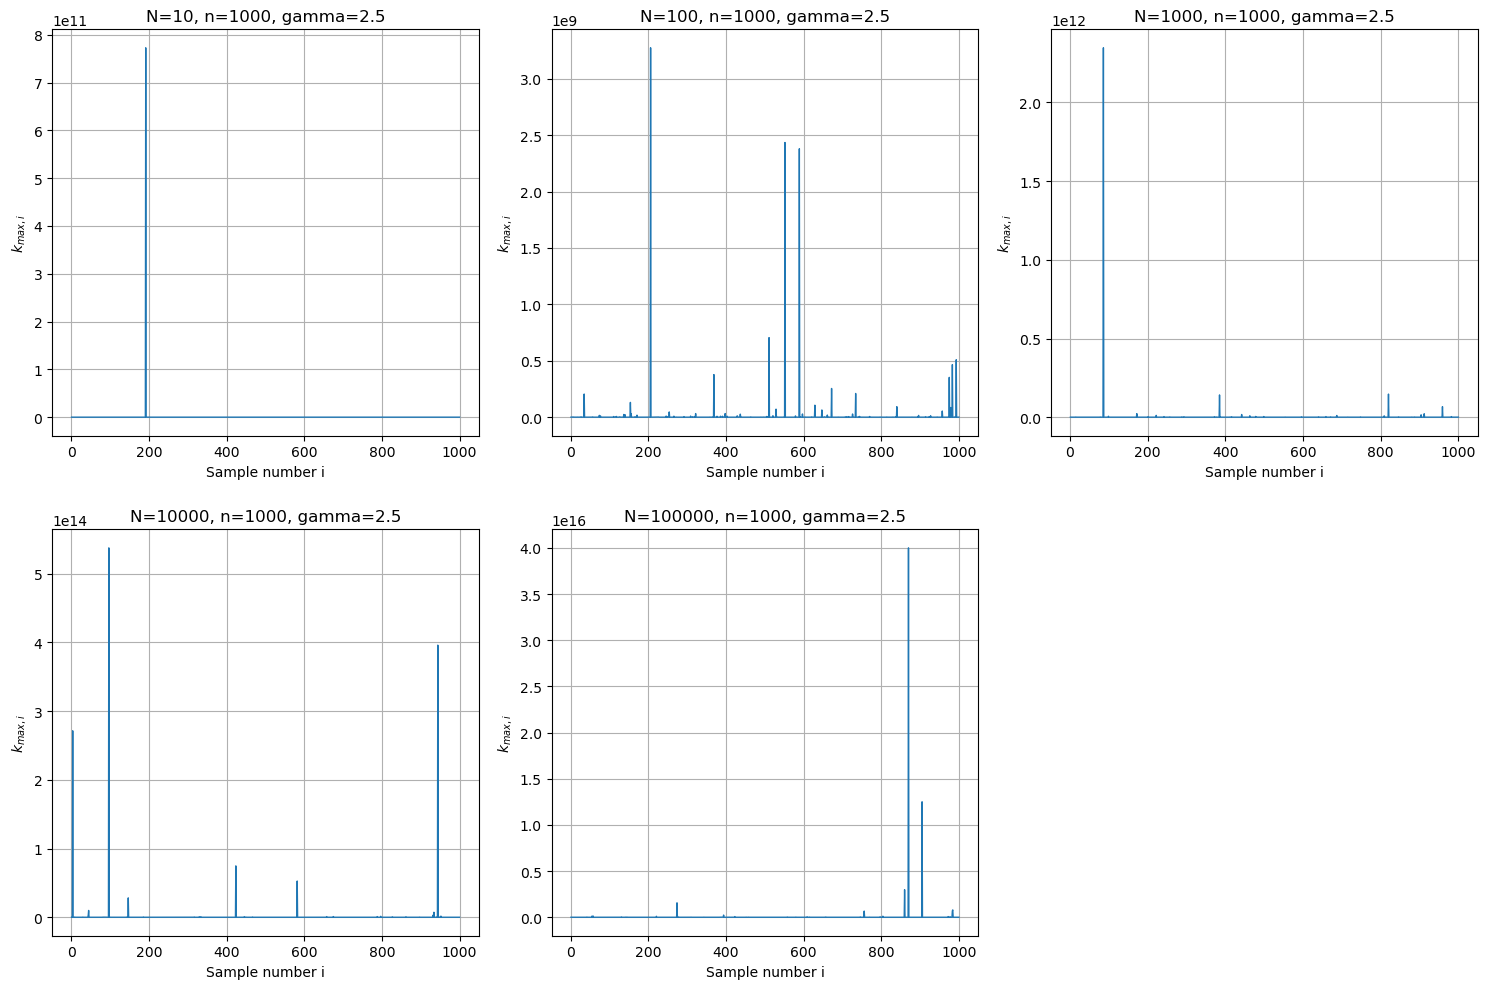

In [12]:
import numpy as np
import matplotlib.pyplot as plt

# Sampling function
def sample_power_law_cdf(size):
    x = np.random.uniform(0, 1, size)  # uniformly distributed between 0 and 1
    
    # This changed
    result = (1 - x) ** (-2)  # power law equation
    k = np.round(result).astype(int)  # round it to nearest integer
    return k.astype(int)

# Parameters
gamma = 5/2  # gamma
n = 1000     # number of sets
N_values = [10, 100, 1000, 10000, 100000]  # list of N
avg_k_max_values = []  # average max list

# Set up the figure for subplots
fig, axes = plt.subplots(2, 3, figsize=(15, 10))  # 2 rows and 3 columns

# Loop over N values
for idx, N in enumerate(N_values):
    
    # List to store max values
    k_max_values = []
    
    # For each N, create n samples
    for i in range(n):
        samples = sample_power_law_cdf(N)  # get the sample
        k_max = np.max(samples)  # get the maximum value
        k_max_values.append(k_max)  # store the max value
    
    # For part B
    avg_k_max = np.mean(k_max_values)  # get the average of the max values
    avg_k_max_values.append(avg_k_max)  # add it to the list
    
    # Plot part A (maxima of samples)
    row = idx // 3  # calculate row for subplot
    col = idx % 3   # calculate column for subplot
    axes[row, col].plot(range(1, n + 1), k_max_values, linestyle='-', linewidth=1)
    axes[row, col].set_title(f'N={N}, n={n}, gamma={gamma}')
    axes[row, col].set_xlabel('Sample number i')
    axes[row, col].set_ylabel('$k_{max,i}$')
    axes[row, col].grid(True)

# Remove the last empty subplot
fig.delaxes(axes[1, 2])

# Adjust layout
plt.tight_layout()
plt.show()

Scaling exponent (slope) = 1.6532 ± 0.2236 (95% CI: [1.2150, 2.0914])
Intercept = 5.6006 ± 0.7415 (95% CI: [4.1473, 7.0539])


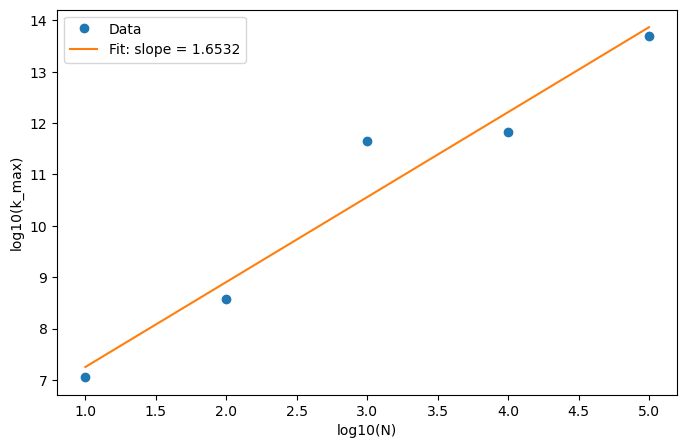

In [10]:
# part b stuff

# confvert lists to arrays
N_values = np.array(N_values)
avg_k_max_values = np.array(avg_k_max_values) 

#helper function for the olits
def linear_log(x, a, b):
    return a * x + b

# log N and max
log_N = np.log10(N_values)
log_k_max = np.log10(avg_k_max_values)

# fit the line
params, covariance = curve_fit(linear_log, log_N, log_k_max)
slope, intercept = params
slope_err, intercept_err = np.sqrt(np.diag(covariance))

# 95% confidnece interval 
z_value = 1.96 
slope_ci = z_value * slope_err
intercept_ci = z_value * intercept_err


# report it all 
print(f"Scaling exponent (slope) = {slope:.4f} ± {slope_err:.4f} (95% CI: [{slope - slope_ci:.4f}, {slope + slope_ci:.4f}])")
print(f"Intercept = {intercept:.4f} ± {intercept_err:.4f} (95% CI: [{intercept - intercept_ci:.4f}, {intercept + intercept_ci:.4f}])")

#plot it all
plt.figure(figsize=(8, 5))
plt.plot(log_N, log_k_max, 'o', label='Data')

# fitted line
plt.plot(log_N, slope * log_N + intercept, '-', label=f'Fit: slope = {slope:.4f}')

plt.xlabel('log10(N)')
plt.ylabel('log10(k_max)')
plt.legend()
plt.show()

# Question 2


In [7]:

#the zeta function we need to solve 
def zeta_func(alpha):
    # using 2 due to the re-indexing i described. Then we subtract by 1 as this zeta function must equal 1 and thus zeta-1=0 is the same
    return sp.zeta(alpha, 2) - 1 

#use solver for alpha 
alpha_solution = fsolve(zeta_func, x_0_starting_est)[0] # solve and get the solution (0 indexing)

alpha_solution

print("The solver's solution for alpha is: ", alpha_solution )

The solver's solution for alpha is:  1.728647238998181


In [3]:

#starting estimate
x_0_starting_est = 1.1

def zeta_func_n(alpha, n):
    result=0
    for j in range(1, n+1): 
         result+=(j + 1)**(-alpha)  
    
    return result-1 
    
n_list=[10**3, 10**4, 10**5, 10**6]
for n in n_list:
     alpha_solution = fsolve(zeta_func_n, x_0_starting_est, args=(n))[0]
     print("For an N of : ", n, " the solver's solution for alpha is: ", alpha_solution )



For an N of :  1000  the solver's solution for alpha is:  1.7235585732112462
For an N of :  10000  the solver's solution for alpha is:  1.727720612455141
For an N of :  100000  the solver's solution for alpha is:  1.728475262642572
For an N of :  1000000  the solver's solution for alpha is:  1.7286151644048664
